In [1]:
from pathlib import Path
from zipfile import ZipFile

WORK_DIR = Path('/content') if Path('/content').exists() else Path.cwd()
required_artifacts = [
    WORK_DIR / 'preprocessed_split.joblib',
    WORK_DIR / 'models' / 'comparison.json',
    WORK_DIR / 'models' / 'candidates' / 'logistic_regression.joblib',
    WORK_DIR / 'models' / 'candidates' / 'naive_bayes.joblib',
    WORK_DIR / 'models' / 'candidates' / 'svm_rbf.joblib',
    WORK_DIR / 'models' / 'candidates' / 'random_forest.joblib',
]
missing = [path for path in required_artifacts if not path.exists()]

if missing and Path('/content').exists():
    from google.colab import files
    print('Đang thiếu các artifact được tạo từ phần 03:')
    for path in missing:
        print(f'- {path}')
    print('Hãy tải lên file stroke_models.zip đã export từ phần 03.')
    uploaded = files.upload()
    archive_path = Path('/content') / next(iter(uploaded))
    with ZipFile(archive_path) as archive:
        archive.extractall('/content')
    missing = [path for path in required_artifacts if not path.exists()]

if missing:
    raise FileNotFoundError(
        'Vẫn còn thiếu artifact: ' + ', '.join(str(path) for path in missing) +
        '. Hãy chạy phần 03 và cell export trước.'
    )

print('Đã có đầy đủ artifact cần thiết cho phần 04.')

Đã có đầy đủ artifact cần thiết cho phần 04.


In [2]:
%pip install -q numpy==2.4.4 pandas==3.0.2 scikit-learn==1.8.0 joblib==1.5.3 matplotlib==3.10.8 seaborn==0.13.2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 04 - Đánh giá, giải thích và đóng gói

Notebook đọc kết quả từ `03_train.ipynb`, đánh giá model trên test đúng một lần, phân tích lỗi và đóng gói model tốt nhất.

## Metric và cách kết luận

- **Recall lớp 1:** tỷ lệ ca stroke thật được phát hiện; ưu tiên cao vì False Negative có rủi ro trong bài toán y tế.
- **Precision lớp 1:** trong các cảnh báo stroke, bao nhiêu cảnh báo đúng; dùng để loại model gần như đoán tất cả là dương tính.
- **F1:** cân bằng Precision và Recall.
- **ROC-AUC:** khả năng xếp hạng xác suất giữa hai lớp, ít phụ thuộc một threshold cụ thể.
- **PR-AUC:** hữu ích khi lớp dương tính hiếm.
- **Confusion matrix:** cho biết trực tiếp TP, TN, FP và FN.

So sánh `cv_best_recall` với `recall_class1` trên test để nhận diện chênh lệch tổng quát hóa. Khi chọn model, không chỉ nhìn metric: còn cân nhắc Precision, thời gian suy luận và kích thước file.

## Quy tắc chọn model

1. Loại model có Precision lớp 1 dưới `0.15` nếu còn model hợp lệ.
2. Trong các model còn lại, chọn Recall test cao nhất.
3. Nếu hòa, chọn ROC-AUC cao hơn.
4. Ghi lý do và metric vào `metadata.json`.

**Artifact:** `model.joblib`, `schema.json`, `metadata.json` và các hình đánh giá được ghi dưới `models/` và `docs/figures/`.

In [3]:
%pip install -q pandas numpy scikit-learn joblib

from pathlib import Path
from datetime import datetime, timezone
import json
import shutil
import time
import joblib
import numpy as np
import pandas as pd
import sklearn
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score

SEARCH_ROOTS = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((root for root in SEARCH_ROOTS if (root / 'ai-models').is_dir()), Path.cwd())
WORK_DIR = Path('/content') if Path('/content').exists() else PROJECT_ROOT / '.colab_artifacts'
MODELS_DIR = WORK_DIR / 'models'
comparison_path = MODELS_DIR / 'comparison.json'
if not comparison_path.exists():
    raise FileNotFoundError('Hay chay 03_train.ipynb truoc de tao models/comparison.json')
with open(comparison_path, encoding='utf-8') as file:
    all_results = json.load(file)

candidate_results = [
    result for result in all_results
    if result.get('model_type', 'candidate') != 'baseline'
    and result['model'] not in {'dummy_baseline', 'baseline_dummy'}
]
if len(candidate_results) != 4:
    raise ValueError(f'Can dung 4 model candidate, nhung nhan duoc {len(candidate_results)} model.')

split = joblib.load(WORK_DIR / 'preprocessed_split.joblib')
X_train, X_test = split['X_train'], split['X_test']
y_train, y_test = split['y_train'], split['y_test']

baseline_started = time.perf_counter()
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_train_seconds = time.perf_counter() - baseline_started
baseline_started = time.perf_counter()
baseline_pred = baseline.predict(X_test)
baseline_inference_ms = (time.perf_counter() - baseline_started) / len(X_test) * 1000
baseline_proba = baseline.predict_proba(X_test)[:, list(baseline.classes_).index(1)]
baseline_row = {
    'model': 'baseline_dummy', 'model_type': 'baseline', 'cv_best_recall': None, 'cv_recall_std': None, 'recall_gap_cv_test': None,
    'recall_class1': round(recall_score(y_test, baseline_pred), 4),
    'precision_class1': round(precision_score(y_test, baseline_pred, zero_division=0), 4),
    'f1_class1': round(f1_score(y_test, baseline_pred, zero_division=0), 4),
    'roc_auc': round(roc_auc_score(y_test, baseline_proba), 4),
    'pr_auc': round(average_precision_score(y_test, baseline_proba), 4),
    'train_seconds': round(baseline_train_seconds, 3), 'inference_ms_per_sample': round(baseline_inference_ms, 3),
    'file_size_kb': None, 'best_params': {'strategy': 'most_frequent'},
}

MIN_PRECISION = 0.15
balanced = [result for result in candidate_results if result['precision_class1'] >= MIN_PRECISION]
pool = balanced or candidate_results
best = sorted(pool, key=lambda result: (result['recall_class1'], result['roc_auc']), reverse=True)[0]
best_name = best['model']
model_table = pd.DataFrame(candidate_results)
model_table['recall_gap_cv_test'] = (model_table['cv_best_recall'] - model_table['recall_class1']).round(4)

def calculate_pr_auc(result):
    candidate_path = MODELS_DIR / 'candidates' / f"{result['model']}.joblib"
    candidate_model = joblib.load(candidate_path)
    candidate_proba = candidate_model.predict_proba(X_test)[:, 1]
    return round(float(average_precision_score(y_test, candidate_proba)), 4)

model_table['pr_auc'] = [calculate_pr_auc(result) for result in candidate_results]
for column in ['cv_recall_std', 'recall_gap_cv_test']:
    model_table[column] = model_table[column].round(4)
comparison_table = pd.concat([pd.DataFrame([baseline_row]), model_table], ignore_index=True)
comparison_table = comparison_table[['model', 'cv_best_recall', 'cv_recall_std', 'recall_class1', 'recall_gap_cv_test', 'precision_class1', 'f1_class1', 'roc_auc', 'pr_auc', 'train_seconds', 'inference_ms_per_sample', 'file_size_kb', 'best_params']]
print(f'Model được chọn: {best_name}')
display(comparison_table)
print('Đã so sánh Dummy baseline với 4 model candidate; Dummy không được chọn làm production.')


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Model được chọn: logistic_regression


,model,cv_best_recall,cv_recall_std,recall_class1,recall_gap_cv_test,precision_class1,f1_class1,roc_auc,pr_auc,train_seconds,inference_ms_per_sample,file_size_kb,best_params
0,baseline_dummy,None,None,0.0000,None,0.0000,0.0000,0.5000,0.0499,0.002,0.000,None,{'strategy': 'most_frequent'}
1,logistic_regression,0.8482,0.0518,0.8039,0.0443,0.1814,0.2960,0.8819,0.4003,5.102,0.063,2.3,{'clf__C': 0.01}
2,naive_bayes,1.0,0.0,1.0000,0.0,0.0580,0.1096,0.8832,0.3689,0.480,0.023,2.6,{'clf__var_smoothing': 1e-09}
3,svm_rbf,0.8434,0.0624,0.7843,0.0591,0.1794,0.2920,0.8757,0.3416,20.824,0.767,54.7,"{'clf__C': 1, 'clf__gamma': 'auto'}"
4,random_forest,0.7111,0.0669,0.6863,0.0248,0.2381,0.3535,0.8821,0.3419,6.244,0.147,542.1,"{'clf__max_depth': 6, 'clf__n_estimators': 200}"


Đã so sánh Dummy baseline với 4 model candidate; Dummy không được chọn làm production.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Đã lưu biểu đồ so sánh: c:\Users\Admin\Desktop\New folder (3)\17_12523101_10123337_DuDoanDotQuy\docs\figures\07_model_comparison.png


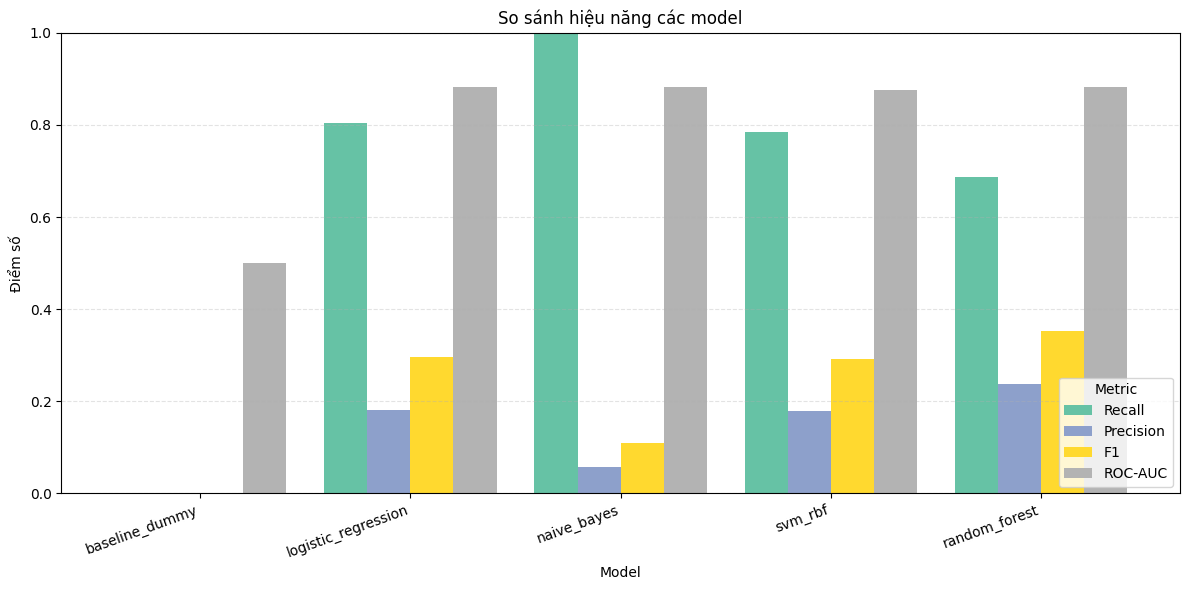

,Recall,Precision,F1,ROC-AUC
model,,,,
baseline_dummy,0.0000,0.0000,0.0000,0.5000
logistic_regression,0.8039,0.1814,0.2960,0.8819
naive_bayes,1.0000,0.0580,0.1096,0.8832
svm_rbf,0.7843,0.1794,0.2920,0.8757
random_forest,0.6863,0.2381,0.3535,0.8821


In [4]:
%pip install -q matplotlib

import matplotlib.pyplot as plt

plot_metrics = ['recall_class1', 'precision_class1', 'f1_class1', 'roc_auc']
plot_labels = {
    'recall_class1': 'Recall',
    'precision_class1': 'Precision',
    'f1_class1': 'F1',
    'roc_auc': 'ROC-AUC',
}
plot_table = comparison_table.set_index('model')[plot_metrics].astype(float)
plot_table = plot_table.rename(columns=plot_labels)

figures_dir = PROJECT_ROOT / 'docs' / 'figures'
if not figures_dir.exists():
    figures_dir = WORK_DIR / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

ax = plot_table.plot(kind='bar', figsize=(12, 6), width=0.82, colormap='Set2')
ax.set_title('So sánh hiệu năng các model')
ax.set_xlabel('Model')
ax.set_ylabel('Điểm số')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend(title='Metric', loc='lower right')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
comparison_figure_path = figures_dir / '07_model_comparison.png'
plt.savefig(comparison_figure_path, dpi=150, bbox_inches='tight')
print(f'Đã lưu biểu đồ so sánh: {comparison_figure_path}')
plt.show()

display(plot_table.round(4))

In [5]:
report_rows = []
for _, row in comparison_table.iterrows():
    model_name = row['model']
    is_baseline = model_name == 'baseline_dummy'
    recall_test = row['recall_class1']
    roc_auc = row['roc_auc']
    precision = row['precision_class1']

    if is_baseline:
        generalization = 'Baseline tham chiếu'
        comment = 'Mốc so sánh, không phải model production.'
    else:
        generalization = f"CV Recall {row['cv_best_recall']:.4f} -> test {recall_test:.4f} (gap {row['recall_gap_cv_test']:+.4f})"
        if model_name == best_name:
            comment = 'Được chọn làm model production.'
        elif precision < MIN_PRECISION:
            comment = f'Không chọn: Precision thấp ({precision:.4f} < {MIN_PRECISION:.2f}).'
        else:
            comment = 'Model hợp lệ nhưng metric chính thấp hơn model được chọn.'

    report_rows.append({
        'Model': model_name,
        'Metric chính (test)': f'Recall {recall_test:.4f}',
        'Metric phụ': f'ROC-AUC {roc_auc:.4f} | Precision {precision:.4f} | F1 {row["f1_class1"]:.4f}',
        'Train so với test': generalization,
        'Thời gian dự đoán': '—' if pd.isna(row['inference_ms_per_sample']) else f"{row['inference_ms_per_sample']:.3f} ms/mẫu",
        'Kích thước file': '—' if pd.isna(row['file_size_kb']) else f"{row['file_size_kb']:.1f} KB",
        'Nhận xét': comment,
    })

report_table = pd.DataFrame(report_rows)
print('Bảng so sánh mẫu (đưa vào báo cáo và slide):')
display(report_table)

Bảng so sánh mẫu (đưa vào báo cáo và slide):


,Model,Metric chính (test),Metric phụ,Train so với test,Thời gian dự đoán,Kích thước file,Nhận xét
0,baseline_dummy,Recall 0.0000,ROC-AUC 0.5000 | Precision 0.0000 | F1 0.0000,Baseline tham chiếu,0.000 ms/mẫu,—,"Mốc so sánh, không phải model production."
1,logistic_regression,Recall 0.8039,ROC-AUC 0.8819 | Precision 0.1814 | F1 0.2960,CV Recall 0.8482 -> test 0.8039 (gap +0.0443),0.063 ms/mẫu,2.3 KB,Được chọn làm model production.
2,naive_bayes,Recall 1.0000,ROC-AUC 0.8832 | Precision 0.0580 | F1 0.1096,CV Recall 1.0000 -> test 1.0000 (gap +0.0000),0.023 ms/mẫu,2.6 KB,Không chọn: Precision thấp (0.0580 < 0.15).
3,svm_rbf,Recall 0.7843,ROC-AUC 0.8757 | Precision 0.1794 | F1 0.2920,CV Recall 0.8434 -> test 0.7843 (gap +0.0591),0.767 ms/mẫu,54.7 KB,Model hợp lệ nhưng metric chính thấp hơn model...
4,random_forest,Recall 0.6863,ROC-AUC 0.8821 | Precision 0.2381 | F1 0.3535,CV Recall 0.7111 -> test 0.6863 (gap +0.0248),0.147 ms/mẫu,542.1 KB,Model hợp lệ nhưng metric chính thấp hơn model...


              precision    recall  f1-score   support

           0     0.9874    0.8095    0.8896       971
           1     0.1814    0.8039    0.2960        51

    accuracy                         0.8092      1022
   macro avg     0.5844    0.8067    0.5928      1022
weighted avg     0.9472    0.8092    0.8600      1022

ROC-AUC: 0.8819 | PR-AUC: 0.4003


,Pred 0,Pred 1
True 0,786,185
True 1,10,41


TN=786, FP=185, FN=10, TP=41


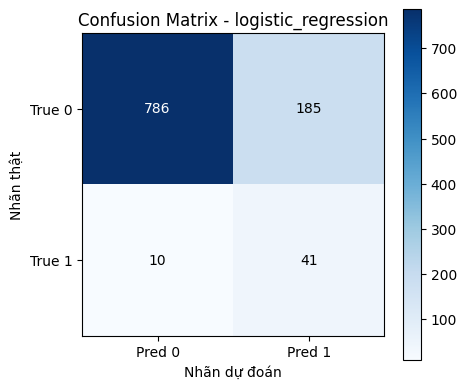

Đã lưu confusion matrix: c:\Users\Admin\Desktop\New folder (3)\17_12523101_10123337_DuDoanDotQuy\docs\figures\08_confusion_matrix_best_model.png
FP cao hon FN: Recall van la uu tien y te, nhung Precision can duoc theo doi de tranh canh bao qua nhieu.
Train/CV vs test: gap lon goi y overfitting; ca hai Recall thap goi y underfitting; gap nho va diem tot cho thay tong quat hoa on dinh.


In [6]:
model = joblib.load(MODELS_DIR / 'candidates' / f'{best_name}.joblib')
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
print(classification_report(y_test, y_pred, digits=4))
print(f'ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}')

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
confusion_table = pd.DataFrame(cm, index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1'])
display(confusion_table)
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')

confusion_figure_path = figures_dir / '08_confusion_matrix_best_model.png'
fig, axis = plt.subplots(figsize=(4.8, 4.2))
image = axis.imshow(cm, interpolation='nearest', cmap='Blues')
axis.figure.colorbar(image, ax=axis)
axis.set(
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['True 0', 'True 1'],
    title=f'Confusion Matrix - {best_name}',
    ylabel='Nhãn thật',
    xlabel='Nhãn dự đoán',
)
threshold = cm.max() / 2.0
for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        axis.text(
            column_index,
            row_index,
            format(cm[row_index, column_index], 'd'),
            ha='center',
            va='center',
            color='white' if cm[row_index, column_index] > threshold else 'black',
        )
fig.tight_layout()
fig.savefig(confusion_figure_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Đã lưu confusion matrix: {confusion_figure_path}')

if fn > fp:
    error_decision = 'FN dang cao hon FP: tiep tuc uu tien Recall va can nhac giam nguong du doan.'
else:
    error_decision = 'FP cao hon FN: Recall van la uu tien y te, nhung Precision can duoc theo doi de tranh canh bao qua nhieu.'
print(error_decision)
print('Train/CV vs test: gap lon goi y overfitting; ca hai Recall thap goi y underfitting; gap nho va diem tot cho thay tong quat hoa on dinh.')

In [7]:
shutil.copyfile(MODELS_DIR / 'candidates' / f'{best_name}.joblib', MODELS_DIR / 'model.joblib')
feature_meta = {
    'age': {'type': 'number', 'label': 'Tuoi', 'min': 0, 'max': 120},
    'avg_glucose_level': {'type': 'number', 'label': 'Muc duong huyet trung binh', 'min': 40, 'max': 300},
    'bmi': {'type': 'number', 'label': 'BMI', 'min': 10, 'max': 100},
    'hypertension': {'type': 'boolean', 'label': 'Cao huyet ap', 'values': [0, 1]},
    'heart_disease': {'type': 'boolean', 'label': 'Benh tim', 'values': [0, 1]},
    'gender': {'type': 'category', 'label': 'Gioi tinh', 'values': ['Male', 'Female', 'Other']},
    'ever_married': {'type': 'category', 'label': 'Da tung ket hon', 'values': ['Yes', 'No']},
    'work_type': {'type': 'category', 'label': 'Loai cong viec', 'values': ['children', 'Govt_job', 'Never_worked', 'Private', 'Self-employed']},
    'Residence_type': {'type': 'category', 'label': 'Noi sinh song', 'values': ['Rural', 'Urban']},
    'smoking_status': {'type': 'category', 'label': 'Tinh trang hut thuoc', 'values': ['formerly smoked', 'never smoked', 'smokes', 'Unknown']},
}
schema = {'target': 'stroke', 'task': 'binary_classification', 'features': [{'name': name, **meta} for name, meta in feature_meta.items()]}
with open(MODELS_DIR / 'schema.json', 'w', encoding='utf-8') as file:
    json.dump(schema, file, ensure_ascii=False, indent=2)
metadata = {
    'model_name': best_name,
    'model_version': '1.0.0',
    'library_versions': {
        'scikit_learn': sklearn.__version__,
        'numpy': np.__version__,
        'pandas': pd.__version__,
    },
    'selected_reason': 'Improves over dummy baseline; highest test Recall among models with precision >= 0.15; tie-break by ROC-AUC, while considering CV stability, latency, and file size.',
    'metrics': {**{k: v for k, v in best.items() if k not in ['model', 'model_path', 'best_params']}, 'pr_auc': round(pr_auc, 4), 'false_positives': int(fp), 'false_negatives': int(fn)},
    'baseline': baseline_row,
    'best_params': best['best_params'],
    'trained_at_utc': datetime.now(timezone.utc).isoformat(),
    'all_models_compared': comparison_table['model'].tolist(),
    'target': 'stroke',
    'positive_class': 1,
}
with open(MODELS_DIR / 'metadata.json', 'w', encoding='utf-8') as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)
print(f'Created model.joblib, schema.json, and metadata.json under {MODELS_DIR}')

Created model.joblib, schema.json, and metadata.json under \content\models


In [8]:
from zipfile import ZipFile

if Path('/content').exists():
    evaluated_download_path = Path('/content/stroke_models_evaluated.zip')
    with ZipFile(evaluated_download_path, 'w') as archive:
        for artifact in MODELS_DIR.rglob('*'):
            if artifact.is_file():
                archive.write(artifact, artifact.relative_to(MODELS_DIR.parent))
        split_artifact = WORK_DIR / 'preprocessed_split.joblib'
        if split_artifact.exists():
            archive.write(split_artifact, split_artifact.name)
    print(f'Created complete download archive: {evaluated_download_path}')
    try:
        from google.colab import files
        files.download(str(evaluated_download_path))
    except ImportError:
        print('Download stroke_models_evaluated.zip manually from the Colab file browser.')
else:
    print(f'Local evaluated artifacts are available at: {MODELS_DIR}')

Created complete download archive: \content\stroke_models_evaluated.zip
Download stroke_models_evaluated.zip manually from the Colab file browser.
